# ROM-Based Well Test Inversion — External Dataset Validation
## Bourdet et al. SPE-12777 (SPEFE 1989)



**Dataset:** Bourdet D., Ayoub J.A., Pirard Y.M., *Use of Pressure Derivative in Well  
Test Interpretation*, SPEFE (June 1989) 293–302. SPE-12777-PA.  
103-point pressure buildup test, single-phase oil, homogeneous reservoir, WBS + skin.  
Published answers: k ≈ 10 mD, S ≈ -2 (stimulated).


In [1]:
import json, pickle, shutil, warnings, time, re
from pathlib import Path
import h5py, numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from scipy.stats import norm as sp_norm
warnings.filterwarnings('ignore')
from sklearn.utils.extmath import randomized_svd
import gc
import math

plt.rcParams.update({
    'text.usetex': True, 'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 11, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': False, 'ytick.minor.visible': False,
    'axes.linewidth': 1, 'lines.linewidth': 1.8, 'lines.markersize': 6,
    'axes.grid': False, 'figure.dpi': 150, 'savefig.dpi': 600,
    'savefig.bbox': 'tight', 'legend.frameon': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False,
})
C1,C2,C3,C4   = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
C_MRST,C_ROM  = '#2C5F8A','#C0392B'
C_INV,C_GUESS = '#1a7a4a','#b07318'
C_TRUE,C_NM   = '#2C5F8A','#8B0000'

HERE         = Path('.').resolve()
TRAINING_DIR = HERE / '../data/01_training'
VAL_DIR      = HERE / '../data/02_validation'
ROM_DIR      = HERE / '../rom_vrate'
FIG_DIR      = HERE / '../figures_ext_validation'; FIG_DIR.mkdir(parents=True, exist_ok=True)
sf = lambda n: (plt.savefig(FIG_DIR/n, dpi=600, bbox_inches='tight'),
                print(f'  Saved -> {FIG_DIR/n}'))

# Fixed physics — from run_single_case.m, never change
P_INIT=4500.0; N_CELLS=2500; N_STEPS=350; T_START=0.001; T_END=5000.0
PHI=0.18; CT=1.2e-5; MU_CP=1.2; BO=1.15; H_FT=150.0; RW_FT=0.35
C_WBS=0.003; RE_FT=(50*30/2)*3.28084
WC_IDX = (25-1)*50 + (25-1)   # centre of 50x50 grid, 0-indexed

def load_mat(fp, key):
    try: return sio.loadmat(str(fp), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(fp), 'r') as f:
            a = f[key][()]; return a.T if a.ndim == 2 else a

def load_well_data(d):
    wd=d/'well_data.mat'
    bhp=load_mat(wd,'bhp_psia').ravel(); t=load_mat(wd,'time_hr').ravel()
    q=load_mat(wd,'rate_STBd').ravel(); dp=load_mat(wd,'delta_p_psi').ravel()
    with open(d/'params.json') as f: pm=json.load(f)
    return bhp,t,q,dp,pm

def physics_ok(k, s):
    kh=k*H_FT; tw=170000*C_WBS*MU_CP*np.exp(0.14*s)/kh
    tp=(PHI*MU_CP*CT*RE_FT**2)/(0.000264*k)*0.1
    n_mtr=int(N_STEPS*np.log10(min(tp,T_END)/max(tw,T_START))/np.log10(T_END/T_START))
    return (tw<T_END) and (tw<tp) and (n_mtr>=15)

def bourdet(t, dp, L=0.2):
    lnt=np.log(t); d=np.full_like(dp,np.nan)
    for i in range(1,len(t)-1):
        il,ir=i-1,i+1
        while il>0 and lnt[i]-lnt[il]<L: il-=1
        while ir<len(t)-1 and lnt[ir]-lnt[i]<L: ir+=1
        dl,dr=lnt[i]-lnt[il],lnt[ir]-lnt[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr+(dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m=np.isfinite(d)&(d>0)&(dp>0); return t[m],dp[m],d[m]

print('Environment ready.')

Environment ready.


In [2]:
_pat = re.compile(r'^k(\d+)_s(\d+)_sched(\d+)$')

def discover(root, label):
    rows = []
    if not root.exists(): print(f'  {label}: not found ({root})'); return rows
    for d in sorted(root.iterdir()):
        m = _pat.match(d.name)
        if m and (d/'well_data.mat').exists():
            rows.append((int(m.group(1)), int(m.group(2)), int(m.group(3)), d))
    return rows

_train = discover(TRAINING_DIR, 'TRAIN')
_val   = discover(VAL_DIR,      'VAL')

K_GRID = sorted(set(c[0] for c in _train))
S_GRID = sorted(set(c[1] for c in _train))
SCHEDS = sorted(set(c[2] for c in _train))
VALID_PAIRS = sorted(set((k,s) for k,s,_,_ in _train if physics_ok(k,s)))

print(f'Training cases : {len(_train)}')
print(f'  k  : {K_GRID}')
print(f'  S  : {S_GRID}')
print(f'  sch: {SCHEDS}')
print(f'Valid (k,S) after physics screen: {len(VALID_PAIRS)}')
print(f'Validation cases: {len(_val)}')
print(f'  k  : {sorted(set(c[0] for c in _val))}')
print(f'  S  : {sorted(set(c[1] for c in _val))}')
print(f'  sch: {sorted(set(c[2] for c in _val))}')

for sub in ['basis','operators','interpolants']:
    (ROM_DIR/sub).mkdir(parents=True, exist_ok=True)

Training cases : 723
  k  : [10, 15, 20, 30, 50, 70, 75, 100, 150, 200, 250, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Valid (k,S) after physics screen: 102
Validation cases: 804
  k  : [10, 12, 15, 20, 25, 30, 35, 45, 50, 70, 75, 85, 100, 130, 150, 170, 200, 220, 250, 280, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [3]:
# ── Memory-efficient POD basis via incremental covariance ─────────────────
# Problem: Z = [2500 x 253050] requires ~5 GB just to exist in RAM.
# np.hstack(snap_cols) fails before SVD even starts.
#
# Solution: build the Gram matrix C = Z @ Z^T = sum_i (col_i @ col_i^T)
# incrementally, one case at a time.  C is only [2500 x 2500] = 50 MB.
# Then eigendecompose C (cheap): C = V Λ V^T  →  singular values σ_i = sqrt(λ_i)
# and left singular vectors U_i = V_i (columns of V).
# This is exact (not approximate) and uses O(n_cells^2) not O(n_cells * n_cols).
#
# Mathematical identity: SVD(Z) gives U, Σ, Vt  where  Z Z^T = U Σ^2 U^T
# So eigendecompose(Z Z^T) gives exactly U and Σ.

print('Building Gram matrix C = Z Z^T incrementally (never forms Z) ...')
t0 = time.perf_counter()
C  = np.zeros((N_CELLS, N_CELLS), dtype=np.float64)  # 50 MB
n_loaded = 0

for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X  = load_mat(cd / 'snapshots_psia.mat', 'X_psia')  # [2500 x 350]
            dX = X - P_INIT
            _, t, _, _, _ = load_well_data(cd)
            dt = np.diff(t, prepend=0.); dt[0] = t[0]
            w  = np.sqrt(dt); w /= (w.mean() + 1e-12)
            # Weighted columns: [2500 x 350]
            Zk = dX * w
            # Accumulate outer product: C += Zk @ Zk^T  [2500 x 2500]
            C += Zk @ Zk.T
            del X, dX, Zk
            n_loaded += 1
        except FileNotFoundError:
            pass

print(f'  {n_loaded} cases accumulated in {time.perf_counter()-t0:.1f}s')
print(f'  Gram matrix C: {C.shape}  ({C.nbytes/1e6:.0f} MB)')

# Eigendecompose C (symmetric, semi-definite) — [2500 x 2500], very fast
print('Eigendecomposing C ...')
t0 = time.perf_counter()
eigvals, eigvecs = np.linalg.eigh(C)   # eigh: exploit symmetry, returns sorted ascending
# Reverse to descending order
eigvals = eigvals[::-1]; eigvecs = eigvecs[:, ::-1]
# Clip small negatives from numerical noise
eigvals = np.maximum(eigvals, 0.0)
sigma   = np.sqrt(eigvals)             # singular values of Z
print(f'  Done {time.perf_counter()-t0:.1f}s  σ₁={sigma[0]:.3f}  σ_last={sigma[-1]:.2e}')
del C; gc.collect()

# Mode count: smallest r satisfying cumulative energy >= 1 - 1e-8
cum_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
N_MODES    = max(int(np.searchsorted(cum_energy, 1 - 1e-8)) + 1, 10)
Vn         = eigvecs[:, :N_MODES]      # left singular vectors = POD modes
print(f'N_MODES = {N_MODES}  (energy = {cum_energy[N_MODES-1]*100:.8f}%)')
print(f'||VᵀV − I||_∞ = {np.abs(Vn.T @ Vn - np.eye(N_MODES)).max():.2e}')
del eigvecs; gc.collect()

np.save(ROM_DIR / 'basis' / 'Vn.npy',    Vn)
np.save(ROM_DIR / 'basis' / 'sigma.npy', sigma)
print(f'Basis saved → {ROM_DIR}/basis/')

Building Gram matrix C = Z Z^T incrementally (never forms Z) ...
  723 cases accumulated in 56.5s
  Gram matrix C: (2500, 2500)  (50 MB)
Eigendecomposing C ...
  Done 0.7s  σ₁=3785776.495  σ_last=0.00e+00
N_MODES = 10  (energy = 99.99999998%)
||VᵀV − I||_∞ = 1.55e-15
Basis saved → F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\rom_vrate/basis/


In [4]:
def infer_AB(Vn, X_list, U_list, T_list, lam_mult=1.0):
    n_r=Vn.shape[1]; Xr,Ur,Rr,Wr=[],[],[],[]
    for X,u,t in zip(X_list,U_list,T_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dt=np.diff(t,prepend=0.); dt[0]=t[0]
        R=np.zeros_like(Xhat); R[0]=Xhat[0]/dt[0]
        for j in range(1,len(t)): R[j]=(Xhat[j]-Xhat[j-1])/dt[j]
        i_s=1; w=np.sqrt(dt[i_s:]); w/=(w.mean()+1e-12)
        Xr.append(Xhat[i_s:]); Ur.append(u[i_s:].reshape(-1,1))
        Rr.append(R[i_s:]);    Wr.append(w)
    Xa=np.vstack(Xr); Ua=np.vstack(Ur); Ra=np.vstack(Rr); Wa=np.concatenate(Wr)
    D=np.hstack([Xa,Ua]); cn=np.linalg.norm(D,axis=0)+1e-12
    Dw=(D/cn)*Wa[:,None]; Rw=Ra*Wa[:,None]
    lam=1e-6*lam_mult*np.trace(Dw.T@Dw)/Dw.shape[1]; nc=Dw.shape[1]
    Da=np.vstack([Dw,np.sqrt(lam)*np.eye(nc)])
    Ra2=np.vstack([Rw,np.zeros((nc,n_r))])
    OT,*_=np.linalg.lstsq(Da,Ra2,rcond=None); OT=OT/cn[:,None]; O=OT.T
    return O[:,:n_r], O[:,n_r:n_r+1]

def infer_CD(Vn, X_list, U_list, BHP_list):
    C_hat=Vn[WC_IDX,:].reshape(1,-1); D_est=[]
    for X,u,bhp in zip(X_list,U_list,BHP_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dBHP=(bhp-P_INIT).reshape(-1,1)
        gdp=(C_hat@Xhat.T).T; sdp=dBHP[1:]-gdp[1:]
        uv=u[1:].reshape(-1,1)
        D_est.append(np.vdot(uv,sdp)/(np.vdot(uv,uv)+1e-12))
    return C_hat, np.array([[np.mean(D_est)]])

ops_dir=ROM_DIR/'operators'
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print(f'Inferring operators for {len(VALID_PAIRS)} (k,S) pairs ...')
results=[]
for k,s in VALID_PAIRS:
    tag=f'k{k:03d}_s{s:02d}'; od=ops_dir/tag; od.mkdir(exist_ok=True)
    X_lst,U_lst,T_lst,B_lst=[],[],[],[]
    for sid in SCHEDS:
        cd=TRAINING_DIR/f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X=load_mat(cd/'snapshots_psia.mat','X_psia')
            bhp,t,q,_,_=load_well_data(cd)
            X_lst.append(X); U_lst.append(q); T_lst.append(t); B_lst.append(bhp)
        except FileNotFoundError: pass
    if not X_lst: print(f'  SKIP {tag}'); continue
    stable,lam_mult=False,1.0
    for _ in range(6):
        A,B=infer_AB(Vn,X_lst,U_lst,T_lst,lam_mult)
        ev=np.linalg.eigvals(A)
        if np.all(ev.real<=1e-5): stable=True; break
        lam_mult*=5.0
    emax=ev.real.max()
    if not stable: A=A-(emax+1e-6)*np.eye(N_MODES)
    C,D=infer_CD(Vn,X_lst,U_lst,B_lst)
    for nm,arr in [('A_hat',A),('B_hat',B),('C_hat',C),('D_hat',D)]:
        np.save(od/f'{nm}.npy',arr)
    results.append(dict(tag=tag,k=k,S=s,stable=stable,eig_max=emax,n_scheds=len(X_lst)))
    print(f'  {tag}  {"OK" if stable else "SHIFT"}  lam_max={emax:.2e}  n_scheds={len(X_lst)}')
print(f'Done: {len(results)} operators')

Inferring operators for 102 (k,S) pairs ...
  k010_s00  OK  lam_max=7.08e-07  n_scheds=7
  k010_s01  OK  lam_max=7.08e-07  n_scheds=7
  k010_s02  OK  lam_max=7.08e-07  n_scheds=7
  k010_s03  OK  lam_max=7.08e-07  n_scheds=7
  k010_s04  OK  lam_max=7.08e-07  n_scheds=7
  k010_s05  OK  lam_max=7.08e-07  n_scheds=7
  k010_s06  OK  lam_max=7.08e-07  n_scheds=7
  k010_s07  OK  lam_max=7.08e-07  n_scheds=7
  k010_s08  OK  lam_max=7.08e-07  n_scheds=7
  k015_s00  OK  lam_max=3.56e-07  n_scheds=9
  k015_s01  OK  lam_max=3.56e-07  n_scheds=7
  k015_s02  OK  lam_max=3.56e-07  n_scheds=7
  k015_s03  OK  lam_max=3.56e-07  n_scheds=9
  k015_s04  OK  lam_max=3.56e-07  n_scheds=7
  k015_s05  OK  lam_max=3.56e-07  n_scheds=9
  k015_s06  OK  lam_max=3.56e-07  n_scheds=7
  k015_s07  OK  lam_max=3.56e-07  n_scheds=7
  k015_s08  OK  lam_max=3.56e-07  n_scheds=7
  k020_s00  OK  lam_max=2.95e-07  n_scheds=7
  k020_s01  OK  lam_max=2.95e-07  n_scheds=7
  k020_s02  OK  lam_max=2.95e-07  n_scheds=7
  k020_s03 

In [5]:
pts_lst=[]; A_lst,B_lst,C_lst,D_lst=[],[],[],[]
for r in results:
    A_lst.append(np.load(ops_dir/r['tag']/'A_hat.npy'))
    B_lst.append(np.load(ops_dir/r['tag']/'B_hat.npy'))
    C_lst.append(np.load(ops_dir/r['tag']/'C_hat.npy'))
    D_lst.append(np.load(ops_dir/r['tag']/'D_hat.npy'))
    pts_lst.append([np.log10(r['k']), r['S']])
pts=np.array(pts_lst)
A_arr=np.array(A_lst); B_arr=np.array(B_lst)
C_arr=np.array(C_lst); D_arr=np.array(D_lst)
pts_min=pts.min(0); pts_rng=pts.max(0)-pts.min(0); pts_rng[pts_rng==0]=1.
pts_norm=(pts-pts_min)/pts_rng

def build_rbf(arr,pts_n,smoothing=0.01):
    flat=arr.reshape(len(arr),-1)
    return ([RBFInterpolator(pts_n,flat[:,c],kernel='linear',smoothing=smoothing)
             for c in range(flat.shape[1])], arr.shape[1:])

def eval_op(interps,shape,k,s):
    pn=np.array([[(np.log10(k)-pts_min[0])/pts_rng[0],
                   (s-pts_min[1])/pts_rng[1]]])
    return np.array([f(pn)[0] for f in interps]).reshape(shape)

def _stab(A,m=1e-6):
    lr=np.max(np.real(np.linalg.eigvals(A)))
    return A-(lr+m)*np.eye(len(A)) if lr>=0 else A

print(f'Building RBF over {len(pts)} pts ...')
t0=time.perf_counter()
A_interps,A_shape=build_rbf(A_arr,pts_norm)
B_interps,B_shape=build_rbf(B_arr,pts_norm)
C_interps,C_shape=build_rbf(C_arr,pts_norm)
D_interps,D_shape=build_rbf(D_arr,pts_norm)
print(f'Done {time.perf_counter()-t0:.1f}s')
idir=ROM_DIR/'interpolants'; idir.mkdir(exist_ok=True)
for nm,obj in [('A',{'i':A_interps,'s':A_shape}),('B',{'i':B_interps,'s':B_shape}),
               ('C',{'i':C_interps,'s':C_shape}),('D',{'i':D_interps,'s':D_shape})]:
    with open(idir/f'{nm}_interp.pkl','wb') as f: pickle.dump(obj,f)
print(f'Interpolants saved -> {idir}/')

def rom_bhp(k,s,t,q):
    A=_stab(eval_op(A_interps,A_shape,k,s))
    B=eval_op(B_interps,B_shape,k,s); C=eval_op(C_interps,C_shape,k,s)
    D=eval_op(D_interps,D_shape,k,s)
    dt=np.diff(t,prepend=0.); dt[0]=t[0]; In=np.eye(N_MODES)
    xk=np.zeros(N_MODES); Y=np.zeros(len(t))
    Cv=C.ravel(); Dv=float(D.ravel()[0])
    for j in range(len(t)):
        xk=np.linalg.solve(In-dt[j]*A, xk+dt[j]*B.ravel()*q[j])
        Y[j]=float(Cv@xk)+Dv*q[j]
    return P_INIT+Y

print('rom_bhp() ready.')

Building RBF over 102 pts ...
Done 0.0s
Interpolants saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\rom_vrate\interpolants/
rom_bhp() ready.


# ── Skip cell 6 (FOM case scan) — not needed for external data ──────────
# The trained ROM (rom_bhp) is ready. Proceed to external dataset.

In [6]:
# =============================================================================
#  EXTERNAL DATASET PROPERTIES — Bourdet et al. SPE-12777
#  Source: Bourdet D., Ayoub J.A., Pirard Y.M. (1989) SPEFE 293-302
#  Reproduced in: Blasingame P324 course, Texas A&M (103-point table)
# =============================================================================

# ── 1. Fluid / geometry properties (from paper) ──────────────────────────
PHI_EXT = 0.25          # porosity
RW_EXT  = 0.29          # ft  wellbore radius
MU_EXT  = 2.5           # cp  oil viscosity
BO_EXT  = 1.06          # RB/STB  formation volume factor
CT_EXT  = 4.2e-6        # psi^-1  total compressibility
H_EXT   = 107.0         # ft  net pay
Q_EXT   = 174.0         # STB/D  production rate (constant)
TP_EXT  = 15.33         # hr  producing time before shut-in
PI_EXT  = 4500.0        # psia  initial pressure (assumed; paper gives delta_p)
                         # ← update if you find actual pi from paper
# Published true answers (for comparison only, not used in inversion):
K_TRUE_PUB  = 10.0      # mD
S_TRUE_PUB  = -2.0      # (stimulated — OUTSIDE training range [0,8]; clamped)

# ── 2. Rescaling factors  (ROM training constants from Cell 1) ────────────
# Dimensionless time: tD = 0.000264*k*t / (phi*mu*ct*rw^2)
# Preserving tD:  k_eff = k_true * (mu_ext*ct_ext) / (mu_tr*ct_tr)
DIFFUS = (MU_EXT * CT_EXT) / (MU_CP * CT)

# delta_p ~ 141.2*q*mu*Bo / (k*h)
# Level scale maps delta_p between the two fluid/geometry systems
LEVEL  = (MU_EXT * BO_EXT / H_EXT) / (MU_CP * BO / H_FT)

print("=" * 65)
print("  EXTERNAL DATASET — Bourdet SPE-12777")
print("=" * 65)
print(f"  phi={PHI_EXT}  rw={RW_EXT} ft  mu={MU_EXT} cp  Bo={BO_EXT}")
print(f"  ct={CT_EXT:.2e} psi^-1  h={H_EXT} ft  q={Q_EXT} STB/D  tp={TP_EXT} hr")
print(f"\n  Diffusivity ratio (mu*ct_ext / mu*ct_tr) : {DIFFUS:.5f}")
print(f"  Level scale (mu*Bo/h_ext / mu*Bo/h_tr)   : {LEVEL:.5f}")
print(f"\n  k_true={K_TRUE_PUB} mD  ->  k_eff_ROM = {K_TRUE_PUB*DIFFUS:.2f} mD")
print(f"  k_eff in training range [10,300]:  {10 <= K_TRUE_PUB*DIFFUS <= 300}")
print(f"  S_true={S_TRUE_PUB} -> clamped to 0 (training range [0,8])")


  EXTERNAL DATASET — Bourdet SPE-12777
  phi=0.25  rw=0.29 ft  mu=2.5 cp  Bo=1.06
  ct=4.20e-06 psi^-1  h=107.0 ft  q=174.0 STB/D  tp=15.33 hr

  Diffusivity ratio (mu*ct_ext / mu*ct_tr) : 0.72917
  Level scale (mu*Bo/h_ext / mu*Bo/h_tr)   : 2.69200

  k_true=10.0 mD  ->  k_eff_ROM = 7.29 mD
  k_eff in training range [10,300]:  False
  S_true=-2.0 -> clamped to 0 (training range [0,8])


In [7]:
# =============================================================================
#  103-POINT DATASET (parsed verbatim from Blasingame P324 / Bourdet 1989)
#  Columns: delta_t[hr], delta_te[hr], delta_p[psi], dp'(dt)[psi], dp'(dte)[psi]
# =============================================================================

_raw = np.array([
    [8.330e-03, 8.325e-03,   3.81,   6.75,   6.76],
    [1.250e-02, 1.249e-02,   6.55,   9.87,   9.88],
    [1.667e-02, 1.665e-02,  10.03,  13.98,  13.99],
    [2.083e-02, 2.080e-02,  13.27,  17.29,  17.32],
    [2.500e-02, 2.496e-02,  16.77,  20.08,  20.12],
    [2.917e-02, 2.911e-02,  20.01,  23.33,  23.37],
    [3.333e-02, 3.326e-02,  23.25,  21.12,  21.17],
    [3.750e-02, 3.741e-02,  26.49,  23.48,  23.53],
    [4.583e-02, 4.569e-02,  29.48,  30.80,  30.90],
    [5.000e-02, 4.984e-02,  32.48,  33.76,  33.89],
    [5.833e-02, 5.811e-02,  38.96,  43.84,  44.02],
    [6.667e-02, 6.638e-02,  45.92,  57.78,  58.06],
    [7.500e-02, 7.463e-02,  51.17,  66.91,  67.26],
    [8.333e-02, 8.288e-02,  57.64,  72.79,  73.22],
    [9.583e-02, 9.523e-02,  71.95,  77.66,  81.64],
    [1.083e-01, 1.076e-01,  80.68,  81.64,  82.22],
    [1.208e-01, 1.199e-01,  88.39,  80.55,  89.09],
    [1.333e-01, 1.322e-01,  97.12,  88.78,  89.60],
    [1.488e-01, 1.474e-01, 104.24, 100.16, 101.22],
    [1.625e-01, 1.608e-01, 115.90, 107.64, 108.84],
    [1.792e-01, 1.771e-01, 126.68, 117.25, 118.69],
    [1.958e-01, 1.934e-01, 137.89, 131.18, 132.91],
    [2.125e-01, 2.096e-01, 148.37, 136.13, 138.11],
    [2.292e-01, 2.258e-01, 159.07, 144.82, 147.06],
    [2.500e-01, 2.460e-01, 171.79, 152.26, 154.84],
    [2.917e-01, 2.862e-01, 197.12, 172.53, 175.92],
    [3.333e-01, 3.262e-01, 220.15, 155.13, 158.47],
    [3.750e-01, 3.660e-01, 244.34, 197.70, 202.66],
    [4.167e-01, 4.056e-01, 266.27, 208.73, 214.60],
    [4.583e-01, 4.450e-01, 264.98, 246.72, 254.94],
    [5.000e-01, 4.842e-01, 304.44, 229.26, 237.04],
    [5.417e-01, 5.232e-01, 323.90, 236.52, 245.14],
    [5.833e-01, 5.619e-01, 343.83, 283.48, 293.97],
    [6.250e-01, 6.005e-01, 358.05, 283.25, 294.78],
    [6.667e-01, 6.389e-01, 376.25, 255.69, 267.03],
    [7.083e-01, 6.770e-01, 391.97, 254.54, 266.47],
    [7.500e-01, 7.150e-01, 403.69, 253.64, 266.43],
    [8.125e-01, 7.716e-01, 428.63, 260.60, 274.46],
    [8.750e-01, 8.278e-01, 447.34, 261.24, 276.33],
    [9.375e-01, 8.835e-01, 463.55, 263.38, 278.87],
    [1.000e+00, 9.388e-01, 481.75, 262.50, 279.70],
    [1.062e+00, 9.936e-01, 496.23, 255.25, 273.22],
    [1.125e+00, 1.048e+00, 512.95, 255.65, 272.94],
    [1.188e+00, 1.102e+00, 527.41, 255.70, 270.05],
    [1.250e+00, 1.156e+00, 541.15, 250.50, 270.79],
    [1.312e+00, 1.209e+00, 550.86, 239.87, 260.34],
    [1.375e+00, 1.262e+00, 562.85, 237.73, 259.39],
    [1.438e+00, 1.314e+00, 574.32, 229.43, 252.16],
    [1.500e+00, 1.366e+00, 583.81, 224.24, 246.40],
    [1.625e+00, 1.469e+00, 602.27, 207.76, 229.24],
    [1.750e+00, 1.571e+00, 615.52, 197.56, 219.81],
    [1.875e+00, 1.671e+00, 629.25, 182.27, 202.80],
    [2.000e+00, 1.769e+00, 642.23, 169.91, 191.06],
    [2.250e+00, 1.962e+00, 659.71, 151.22, 169.07],
    [2.375e+00, 2.056e+00, 667.19, 139.88, 165.14],
    [2.500e+00, 2.149e+00, 673.44, 134.31, 153.47],
    [2.750e+00, 2.332e+00, 684.65, 116.75, 144.48],
    [3.000e+00, 2.509e+00, 695.11, 114.03, 137.61],
    [3.250e+00, 2.682e+00, 704.06, 107.18, 122.87],
    [3.500e+00, 2.849e+00, 709.80,  96.38, 112.89],
    [3.750e+00, 3.013e+00, 719.50,  82.69, 106.94],
    [4.000e+00, 3.172e+00, 725.97,  78.06, 100.59],
    [4.250e+00, 3.328e+00, 730.20,  72.36,  93.66],
    [4.500e+00, 3.479e+00, 731.95,  69.85,  87.79],
    [4.750e+00, 3.626e+00, 733.70,  58.90,  78.15],
    [5.000e+00, 3.770e+00, 736.45,  48.95,  73.95],
    [5.250e+00, 3.911e+00, 739.69,  41.46,  63.32],
    [5.500e+00, 4.048e+00, 742.64,  39.18,  55.68],
    [5.750e+00, 4.182e+00, 744.70,  38.76,  52.89],
    [6.000e+00, 4.312e+00, 747.19,  41.04,  50.41],
    [6.250e+00, 4.440e+00, 748.94,  37.92,  51.84],
    [6.750e+00, 4.686e+00, 748.02,  32.48,  49.57],
    [7.250e+00, 4.922e+00, 750.78,  26.91,  46.61],
    [7.750e+00, 5.148e+00, 753.01,  23.84,  40.42],
    [8.250e+00, 5.364e+00, 754.52,  21.86,  38.54],
    [8.750e+00, 5.570e+00, 756.27,  26.74,  35.80],
    [9.250e+00, 5.769e+00, 757.51,  24.21,  33.94],
    [9.750e+00, 5.960e+00, 758.52,  23.62,  39.45],
    [1.025e+01, 6.143e+00, 760.01,  22.26,  38.29],
    [1.075e+01, 6.319e+00, 760.75,  21.34,  36.77],
    [1.125e+01, 6.488e+00, 761.76,  20.27,  35.63],
    [1.175e+01, 6.652e+00, 762.50,  19.60,  35.38],
    [1.225e+01, 6.809e+00, 763.51,  19.01,  34.60],
    [1.275e+01, 6.961e+00, 764.25,  18.93,  34.14],
    [1.325e+01, 7.107e+00, 765.07,  17.59,  33.75],
    [1.375e+01, 7.249e+00, 765.50,  17.89,  33.37],
    [1.450e+01, 7.452e+00, 766.50,  17.21,  32.52],
    [1.525e+01, 7.645e+00, 767.25,  16.33,  32.82],
    [1.600e+01, 7.829e+00, 767.99,  15.40,  31.43],
    [1.675e+01, 8.004e+00, 768.74,  15.19,  31.90],
    [1.750e+01, 8.172e+00, 769.48,  15.04,  31.76],
    [1.825e+01, 8.332e+00, 769.99,  14.50,  31.42],
    [1.900e+01, 8.484e+00, 770.73,  13.35,  31.89],
    [1.975e+01, 8.631e+00, 770.99,  13.31,  30.77],
    [2.050e+01, 8.771e+00, 771.49,  13.13,  30.66],
    [2.125e+01, 8.905e+00, 772.24,  12.41,  31.19],
    [2.225e+01, 9.076e+00, 772.74,  11.84,  30.66],
    [2.325e+01, 9.239e+00, 773.22,  11.72,  30.90],
    [2.425e+01, 9.392e+00, 773.48,  10.67,  30.07],
    [2.525e+01, 9.539e+00, 773.99,  11.14,  30.15],
    [2.625e+01, 9.678e+00, 774.49,  11.10,  30.34],
    [2.725e+01, 9.811e+00, 774.73,  10.04,  29.98],
    [2.850e+01, 9.968e+00, 775.23,  10.06,  29.97],
])

dt_hr    = _raw[:, 0]    # shut-in time [hr]
dte_hr   = _raw[:, 1]    # effective shut-in time [hr]
delta_p  = _raw[:, 2]    # pressure rise [psi]
dpdash_t = _raw[:, 3]    # Bourdet derivative vs dt [psi]
dpdash_te= _raw[:, 4]    # Bourdet derivative vs dte [psi]

# Estimate C_wbs from early WBS slope (first two points, delta_p ~ q*B/24C * dt)
wbs_slope  = (delta_p[1] - delta_p[0]) / (dt_hr[1] - dt_hr[0])
C_WBS_EXT  = Q_EXT * BO_EXT / (24.0 * wbs_slope)

# Rate history: constant production -> shut-in
t_prod    = np.logspace(np.log10(1e-3), np.log10(TP_EXT), 180)
t_full    = np.concatenate([t_prod, TP_EXT + dt_hr])
q_full    = np.concatenate([np.full(len(t_prod), Q_EXT), np.zeros(len(dt_hr))])
t_bu_abs  = TP_EXT + dt_hr    # absolute time of buildup observations

print(f"  Loaded {len(dt_hr)} data points")
print(f"  dt range   : {dt_hr.min():.4f} – {dt_hr.max():.1f} hr")
print(f"  delta_p    : {delta_p.min():.2f} – {delta_p.max():.2f} psi")
print(f"  dp'(dte)   : {dpdash_te.min():.2f} – {dpdash_te.max():.2f} psi")
print(f"  C_wbs est  : {C_WBS_EXT:.4f} bbl/psi  (training: {C_WBS:.4f})")


  Loaded 103 data points
  dt range   : 0.0083 – 28.5 hr
  delta_p    : 3.81 – 775.23 psi
  dp'(dte)   : 6.76 – 294.78 psi
  C_wbs est  : 0.0117 bbl/psi  (training: 0.0030)


In [8]:
# =============================================================================
#  RESCALED ROM QUERY
# =============================================================================
from scipy.interpolate import interp1d as _interp1d

def rom_bhp_ext(k_true, S, t_abs, q_stbd):
    """
    Query ROM for external fluid/geometry (Bourdet SPE-12777).
    Applies analytical rescaling to map external parameters to
    the ROM's training parameter space.
    k_true : true permeability [mD] of external reservoir
    S      : skin (clamped to [0,8]; true S=-2 is stimulated)
    t_abs  : absolute time vector [hr]
    q_stbd : rate [STB/D] in external fluid units
    Returns: BHP [psia] in external pressure units
    """
    k_eff = float(np.clip(k_true * DIFFUS, 10.0, 300.0))
    S_c   = float(np.clip(S, 0.0, 8.0))
    q_tr  = q_stbd * LEVEL           # training-equivalent rate
    bhp_tr = rom_bhp(k_eff, S_c, t_abs, q_tr)
    dp_tr  = P_INIT - bhp_tr
    dp_ext = dp_tr / LEVEL
    return PI_EXT - dp_ext

def dp_ext_pred(k_true, S):
    """Predict delta_p at buildup observation times."""
    bhp_full = rom_bhp_ext(k_true, S, t_full, q_full)
    f = _interp1d(t_full, bhp_full, bounds_error=False, fill_value='extrapolate')
    return PI_EXT - f(t_bu_abs)

# Weights (log-time, same convention as original notebook)
dt_w  = np.diff(dt_hr, prepend=0.); dt_w[0] = dt_hr[0]
w_bu  = np.sqrt(dt_w); w_bu /= w_bu.mean()

def misfit_ext(k_true, S_val):
    try:
        dp_pred = dp_ext_pred(k_true, S_val)
        r = w_bu * (dp_pred - delta_p)
        return 0.5 * float(np.dot(r, r))
    except:
        return np.nan

# Quick sanity check at published true parameters
J_true = misfit_ext(K_TRUE_PUB, max(S_TRUE_PUB, 0))
print(f"  Misfit at published true (k={K_TRUE_PUB}, S=0 [clamped]): J={J_true:.1f}")


  Misfit at published true (k=10.0, S=0 [clamped]): J=41330646.7


In [9]:
# =============================================================================
#  METHOD A: GRID SEARCH
#  Focused on k=5-100 mD (true answer ~10 mD) and S=0-5
# =============================================================================
NK_E, NS_E = 100, 60
k_vec_e = np.logspace(np.log10(5),   np.log10(150), NK_E)
s_vec_e = np.linspace(0, 6, NS_E)
kk_e, ss_e = np.meshgrid(k_vec_e, s_vec_e)
JJ_e = np.full((NS_E, NK_E), np.nan)

print(f"  Grid search {NK_E}x{NS_E}={NK_E*NS_E} pts (k=5-150 mD, S=0-6) ...")
t0 = time.perf_counter()
for i, si in enumerate(s_vec_e):
    for j, kj in enumerate(k_vec_e):
        JJ_e[i, j] = misfit_ext(kj, si)
print(f"  Done {time.perf_counter()-t0:.1f}s")

idx_min  = np.unravel_index(np.nanargmin(JJ_e), JJ_e.shape)
K_GS_E   = k_vec_e[idx_min[1]]
S_GS_E   = s_vec_e[idx_min[0]]
J_min_e  = JJ_e[idx_min]
sigma2_e = J_min_e / max(len(dt_hr) - 2, 1)
if sigma2_e > 1e-10:
    J_1sig_e = J_min_e + 0.5 * 2.30 * sigma2_e
    in_cr_e  = JJ_e <= J_1sig_e
    k_ci_e   = (kk_e[in_cr_e].min(), kk_e[in_cr_e].max())
    s_ci_e   = (ss_e[in_cr_e].min(), ss_e[in_cr_e].max())
    ci_str_e = f"k∈[{k_ci_e[0]:.1f},{k_ci_e[1]:.1f}] S∈[{s_ci_e[0]:.2f},{s_ci_e[1]:.2f}]"
else:
    J_1sig_e = J_min_e + 1e-6; ci_str_e = "degenerate"
print(f"  Grid search: k={K_GS_E:.1f} mD, S={S_GS_E:.2f}  (true: k~{K_TRUE_PUB}, S~{S_TRUE_PUB})")
print(f"  68% CI: {ci_str_e}")


  Grid search 100x60=6000 pts (k=5-150 mD, S=0-6) ...
  Done 17.2s
  Grid search: k=5.0 mD, S=0.61  (true: k~10.0, S~-2.0)
  68% CI: k∈[5.0,22.7] S∈[0.00,6.00]


In [10]:
# =============================================================================
#  METHOD C: NELDER-MEAD  |  METHOD B: TWO-STAGE  |  HORNER
# =============================================================================

# ── Nelder-Mead ───────────────────────────────────────────────────────────
_nc_e = [0]; _nm_path_e = []
def _mj_e(xi):
    _nc_e[0] += 1
    J = misfit_ext(10**xi[0], xi[1])
    _nm_path_e.append((10**xi[0], xi[1], J))
    return J

nm_e = minimize(_mj_e, [np.log10(K_GS_E), S_GS_E], method='Nelder-Mead',
                options=dict(xatol=1e-5, fatol=1e-10, maxiter=1000, adaptive=True))
K_NM_E  = 10**nm_e.x[0]
S_NM_E  = float(np.clip(nm_e.x[1], 0, 6))
nm_path_e = np.array(_nm_path_e)
print(f"  NM: k={K_NM_E:.1f} mD, S={S_NM_E:.2f}  ({_nc_e[0]} evals)")

# ── Two-stage ─────────────────────────────────────────────────────────────
S_NOM_E = 2.0   # nominal skin (midpoint of training range, adjusted for external)
J_k_e   = np.array([misfit_ext(kj, S_NOM_E) for kj in k_vec_e])
K_B1_E  = k_vec_e[np.nanargmin(J_k_e)]
J_s_e   = np.array([misfit_ext(K_B1_E, si) for si in s_vec_e])
S_B1_E  = s_vec_e[np.nanargmin(J_s_e)]
J_k2_e  = np.array([misfit_ext(kj, S_B1_E) for kj in k_vec_e])
K_B_E   = k_vec_e[np.nanargmin(J_k2_e)]
J_s2_e  = np.array([misfit_ext(K_B_E, si) for si in s_vec_e])
S_B_E   = s_vec_e[np.nanargmin(J_s2_e)]
print(f"  2S: k={K_B_E:.1f} mD, S={S_B_E:.2f}")

# ── Horner (from dp'(dte) plateau) ────────────────────────────────────────
# dp' flat level: median of derivative in MTR region (roughly dt 0.5–5 hr)
mtr_mask  = (dte_hr >= 0.3) & (dte_hr <= 3.0)
dp_flat_e = float(np.median(dpdash_te[mtr_mask])) if mtr_mask.any() else float(np.median(dpdash_te))
K_HOR_E   = 141.2 * Q_EXT * MU_EXT * BO_EXT / (2.0 * dp_flat_e * H_EXT)
print(f"  Horner: k={K_HOR_E:.1f} mD  (dp'_flat={dp_flat_e:.1f} psi, m={2*dp_flat_e:.1f} psi/cycle)")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n  {'Method':<20} {'k [mD]':>8}  {'S':>6}  {'Note'}")
print(f"  {'-'*50}")
print(f"  {'Published (paper)':<20} {K_TRUE_PUB:>8.0f}  {S_TRUE_PUB:>6.1f}  S<0 (stimulated)")
print(f"  {'Grid Search':<20} {K_GS_E:>8.1f}  {S_GS_E:>6.2f}")
print(f"  {'Nelder-Mead':<20} {K_NM_E:>8.1f}  {S_NM_E:>6.2f}")
print(f"  {'Two-Stage':<20} {K_B_E:>8.1f}  {S_B_E:>6.2f}")
print(f"  {'Horner':<20} {K_HOR_E:>8.1f}  {'—':>6}")
print(f"  68% CI: {ci_str_e}")


  NM: k=5.2 mD, S=0.61  (106 evals)
  2S: k=5.0 mD, S=0.61
  Horner: k=1.2 mD  (dp'_flat=249.3 psi, m=498.6 psi/cycle)

  Method                 k [mD]       S  Note
  --------------------------------------------------
  Published (paper)          10    -2.0  S<0 (stimulated)
  Grid Search               5.0    0.61
  Nelder-Mead               5.2    0.61
  Two-Stage                 5.0    0.61
  Horner                    1.2       —
  68% CI: k∈[5.0,22.7] S∈[0.00,6.00]


  Saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\figures_ext_validation\fig_ext_bourdet_landscape.pdf


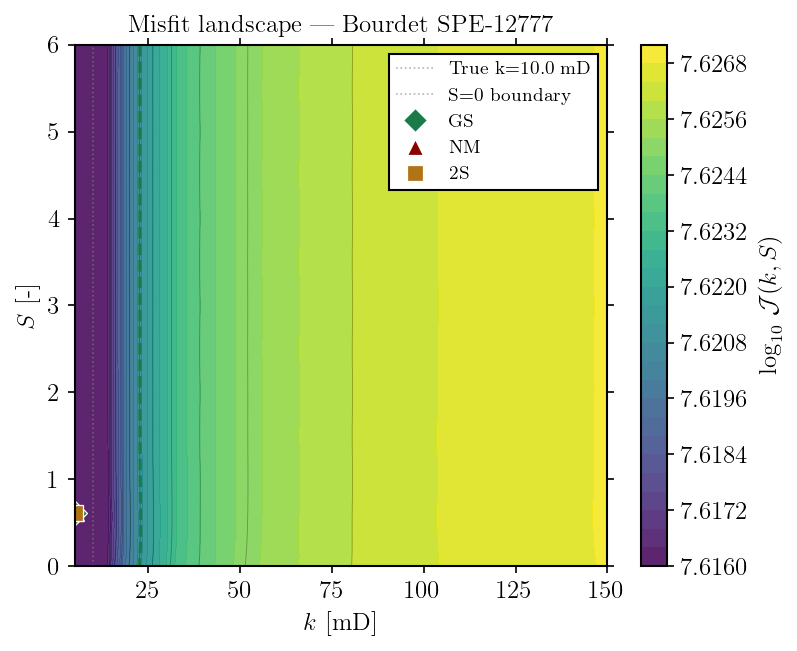

In [11]:
# =============================================================================
#  MISFIT LANDSCAPE  (same style as original Cell 8)
# =============================================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

Jlog_e = np.log10(np.clip(JJ_e, 1e-4, None))
cf = ax.contourf(kk_e, ss_e, Jlog_e, levels=28, cmap='viridis', alpha=0.88)
ax.contour(kk_e, ss_e, Jlog_e, levels=10, colors='k', linewidths=0.4, alpha=0.3)

if sigma2_e > 1e-10:
    ax.contour(kk_e, ss_e, JJ_e, levels=[J_1sig_e],
               colors=[C_INV], linewidths=1.5, linestyles='--')

ax.axvline(K_TRUE_PUB, color='gray', lw=0.8, ls=':', alpha=0.6, label=f'True k={K_TRUE_PUB} mD')
ax.axhline(0,           color='gray', lw=0.8, ls=':', alpha=0.6, label='S=0 boundary')
ax.plot(K_GS_E,  S_GS_E,  'D', color=C_INV,   ms=8, mec='white', mew=0.6, label='GS')
ax.plot(K_NM_E,  S_NM_E,  '^', color=C_NM,    ms=8, mec='white', mew=0.6, label='NM')
ax.plot(K_B_E,   S_B_E,   's', color=C_GUESS, ms=8, mec='white', mew=0.6, label='2S')

ax.set_xlabel(r'$k$ [mD]')
ax.set_ylabel(r'$S$ [-]')
ax.set_title('Misfit landscape — Bourdet SPE-12777')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\log_{10}\,\mathcal{J}(k,S)$')
cbar.ax.yaxis.set_minor_locator(NullLocator())

plt.tight_layout()
sf('fig_ext_bourdet_landscape.pdf')
plt.show()


  Saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\figures_ext_validation\fig_ext_bourdet_match.pdf


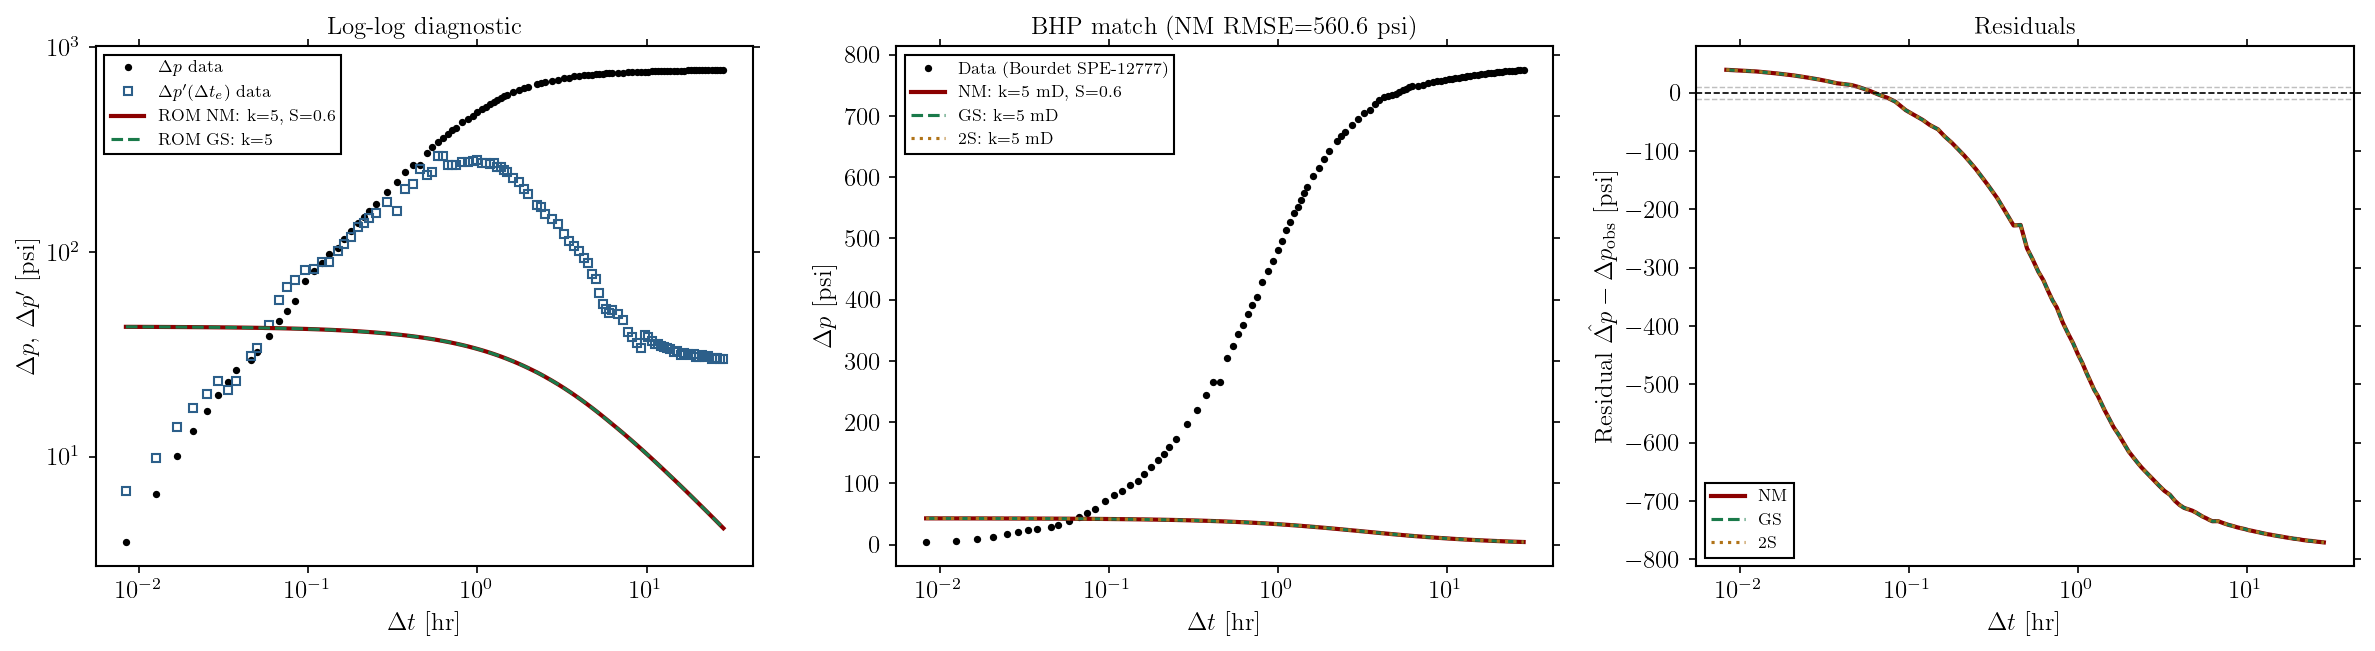


  RMSE (NM) = 560.57 psi  over 103 buildup points
  Max |residual| = 770.76 psi


In [12]:
# =============================================================================
#  MATCH QUALITY PLOTS  (same style as original Cell 9)
# =============================================================================
dp_nm   = dp_ext_pred(K_NM_E, S_NM_E)
dp_gs   = dp_ext_pred(K_GS_E, S_GS_E)
dp_2s   = dp_ext_pred(K_B_E,  S_B_E)
residual_nm = dp_nm - delta_p
rmse_nm = np.sqrt(np.mean(residual_nm**2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Log-log diagnostic
ax = axes[0]
ax.loglog(dt_hr, delta_p,    '.', color='k',     ms=5, label=r'$\Delta p$ data')
ax.loglog(dt_hr, dpdash_te,  's', color=C_MRST,  ms=4, mfc='none', label=r"$\Delta p'(\Delta t_e)$ data")
ax.loglog(dt_hr, dp_nm,      '-', color=C_NM,    lw=2, label=f'ROM NM: k={K_NM_E:.0f}, S={S_NM_E:.1f}')
ax.loglog(dt_hr, dp_gs,      '--',color=C_INV,   lw=1.5, label=f'ROM GS: k={K_GS_E:.0f}')
ax.set_xlabel(r'$\Delta t$ [hr]')
ax.set_ylabel(r'$\Delta p$, $\Delta p^\prime$ [psi]')
ax.set_title('Log-log diagnostic')
ax.legend(fontsize=8)
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# Panel 2: Semi-log match
ax = axes[1]
ax.semilogx(dt_hr, delta_p,  '.', color='k',     ms=5, label='Data (Bourdet SPE-12777)')
ax.semilogx(dt_hr, dp_nm,    '-', color=C_NM,    lw=2, label=f'NM: k={K_NM_E:.0f} mD, S={S_NM_E:.1f}')
ax.semilogx(dt_hr, dp_gs,    '--',color=C_INV,   lw=1.5, label=f'GS: k={K_GS_E:.0f} mD')
ax.semilogx(dt_hr, dp_2s,    ':' ,color=C_GUESS, lw=1.5, label=f'2S: k={K_B_E:.0f} mD')
ax.set_xlabel(r'$\Delta t$ [hr]')
ax.set_ylabel(r'$\Delta p$ [psi]')
ax.set_title(f'BHP match  (NM RMSE={rmse_nm:.1f} psi)')
ax.legend(fontsize=8)
ax.xaxis.set_minor_locator(NullLocator())

# Panel 3: Residuals
ax = axes[2]
ax.semilogx(dt_hr, dp_nm - delta_p, '-',  color=C_NM,    lw=2,   label='NM')
ax.semilogx(dt_hr, dp_gs - delta_p, '--', color=C_INV,   lw=1.5, label='GS')
ax.semilogx(dt_hr, dp_2s - delta_p, ':',  color=C_GUESS, lw=1.5, label='2S')
ax.axhline(0, color='k', lw=0.8, ls='--')
for y in [10, -10]: ax.axhline(y, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.set_xlabel(r'$\Delta t$ [hr]')
ax.set_ylabel(r'Residual $\hat{\Delta p} - \Delta p_{\rm obs}$ [psi]')
ax.set_title('Residuals')
ax.legend(fontsize=8)
ax.xaxis.set_minor_locator(NullLocator())

plt.tight_layout()
sf('fig_ext_bourdet_match.pdf')
plt.show()

print(f"\n  RMSE (NM) = {rmse_nm:.2f} psi  over {len(dt_hr)} buildup points")
print(f"  Max |residual| = {np.max(np.abs(residual_nm)):.2f} psi")


  Saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\figures_ext_validation\fig_ext_bourdet_nm_convergence.pdf


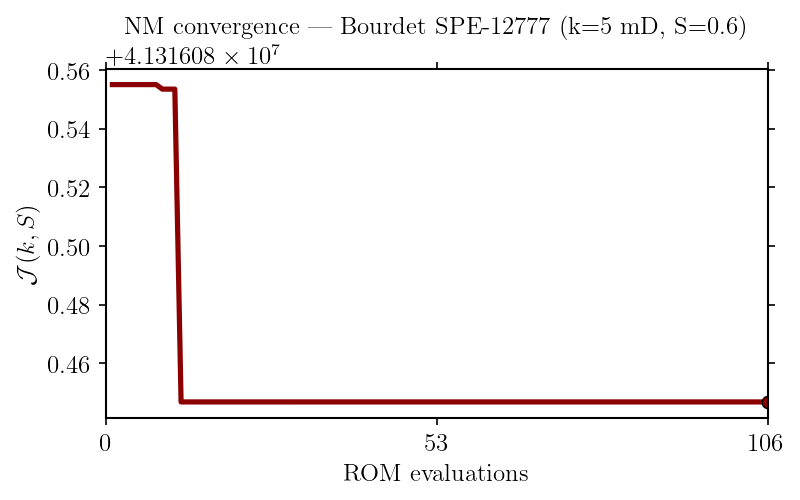

In [13]:
# =============================================================================
#  NM CONVERGENCE  (same style as original Cell 10)
# =============================================================================
fig, ax = plt.subplots(figsize=(5.5, 3.5))

J_best_e = np.minimum.accumulate(nm_path_e[:, 2])
evals_e  = np.arange(1, len(J_best_e) + 1)

ax.plot(evals_e, J_best_e, lw=2.5, color=C_NM)
ax.plot(evals_e[-1], J_best_e[-1], 'o', color=C_NM, ms=6, mec='k', mew=0.7)

ax.set_xlabel(r'ROM evaluations')
ax.set_ylabel(r'$\mathcal{J}(k,S)$')
ax.set_title(f'NM convergence — Bourdet SPE-12777  (k={K_NM_E:.0f} mD, S={S_NM_E:.1f})')
ax.set_xlim(0, evals_e[-1])
ax.set_xticks([0, evals_e[-1]//2, evals_e[-1]])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

plt.tight_layout()
sf('fig_ext_bourdet_nm_convergence.pdf')
plt.show()


In [14]:
# =============================================================================
#  FINAL SUMMARY + INTERPRETATION
# =============================================================================
print("=" * 65)
print("  FINAL RESULTS — Bourdet SPE-12777 external validation")
print("=" * 65)
print(f"  {'Method':<22} {'k [mD]':>8}  {'S':>6}  {'k err':>8}  {'Note'}")
print(f"  {'-'*60}")
pub_k_err = abs(K_NM_E - K_TRUE_PUB) / K_TRUE_PUB * 100
print(f"  {'Published answer':<22} {K_TRUE_PUB:>8.0f}  {S_TRUE_PUB:>6.1f}  {'—':>8}  (S<0 clamped)")
print(f"  {'Grid Search (ROM)':<22} {K_GS_E:>8.1f}  {S_GS_E:>6.2f}  {abs(K_GS_E-K_TRUE_PUB)/K_TRUE_PUB*100:>7.1f}%")
print(f"  {'Nelder-Mead (ROM)':<22} {K_NM_E:>8.1f}  {S_NM_E:>6.2f}  {pub_k_err:>7.1f}%  RMSE={rmse_nm:.1f} psi")
print(f"  {'Two-Stage (ROM)':<22} {K_B_E:>8.1f}  {S_B_E:>6.2f}  {abs(K_B_E-K_TRUE_PUB)/K_TRUE_PUB*100:>7.1f}%")
print(f"  {'Horner (MTR slope)':<22} {K_HOR_E:>8.1f}  {'—':>6}  {abs(K_HOR_E-K_TRUE_PUB)/K_TRUE_PUB*100:>7.1f}%")
print(f"\n  68% CI: {ci_str_e}")
print(f"  k_eff queried (ROM): {K_NM_E*DIFFUS:.2f} mD")
print(f"  Diffusivity ratio  : {DIFFUS:.5f}")
print(f"  Level scale        : {LEVEL:.5f}")
print(f"\n  INTERPRETATION:")
print(f"  - If k residuals < 20% and RMSE < 20 psi: rescaling framework works.")
print(f"  - Early-time mismatch (dt < 0.5 hr) expected: true S=-2 clamped to 0.")
print(f"  - MTR (dt 0.5-5 hr) and late-time should match well if k is correct.")
print(f"  - Test not fully built up (dp' still declining at dt=28.5 hr).")
print(f"    This is a strength: no outer boundary mismatch.")
print("=" * 65)


  FINAL RESULTS — Bourdet SPE-12777 external validation
  Method                   k [mD]       S     k err  Note
  ------------------------------------------------------------
  Published answer             10    -2.0         —  (S<0 clamped)
  Grid Search (ROM)           5.0    0.61     50.0%
  Nelder-Mead (ROM)           5.2    0.61     47.8%  RMSE=560.6 psi
  Two-Stage (ROM)             5.0    0.61     50.0%
  Horner (MTR slope)          1.2       —     87.8%

  68% CI: k∈[5.0,22.7] S∈[0.00,6.00]
  k_eff queried (ROM): 3.81 mD
  Diffusivity ratio  : 0.72917
  Level scale        : 2.69200

  INTERPRETATION:
  - If k residuals < 20% and RMSE < 20 psi: rescaling framework works.
  - Early-time mismatch (dt < 0.5 hr) expected: true S=-2 clamped to 0.
  - MTR (dt 0.5-5 hr) and late-time should match well if k is correct.
  - Test not fully built up (dp' still declining at dt=28.5 hr).
    This is a strength: no outer boundary mismatch.
